In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import boto3
import datetime as dt

In [2]:
dtm_now = dt.datetime.now()
print(f'Latest run date: {dtm_now}')

Latest run date: 2025-03-03 20:34:46.470974


#### Functions

In [3]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

# output
str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# current approval rate
flt_current_approval_rate = 0.20

Project: 20231010-gen-xii
Task: ad_hoc
Subtask: 09_policy_simulation


#### Make output dir

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Load in data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://20250121-gen-13-model-monitoring/10_compare_debtor/{str_filename}'
df = pd.read_parquet(str_uri)
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)
# drop dup rows
df.drop_duplicates(subset=['accountid','bitdebtor'], keep='last', inplace=True)
# n accounts
int_naccounts = df['accountid'].nunique()
# bk
df['ENG-bk'] = df['intopenbktype__app'].apply(
    lambda x: 1 if pd.notnull(x) else 0,
)
print(f'N Accounts: {int_naccounts}')
# show
df

N Accounts: 153287


,accountid,bitdebtor,pd_gen12,lgd_gen12,pd_gen13,lgd_gen13,funded,request_datetime,response_model_name,file_name,...,FIG TECH INC_tag,SELF/RENT_tag,SELFBILLSE_tag,PROGRESSRES_tag,FLEX_tag,FLEXFINANCE_tag,sum,has_inst_tag,ENG-loan_to_value,ENG-bk
0,8427704,1,0.206142,0.568248,0.129986,0.277756,0,2024-11-27 00:00:11-07:00,PRESTIGE-GEN-XII,8427704/w7Hr-2024-11-27-00:00:11,...,0,0,0,0,0,0,0,0,0.877860,0
1,8427704,0,0.079544,0.514933,0.066810,0.277756,0,2024-11-27 00:00:11-07:00,PRESTIGE-GEN-XII,8427704/w7Hr-2024-11-27-00:00:11,...,0,0,0,0,0,0,0,0,0.877860,0
2,8427707,1,0.165303,0.611415,0.452960,0.277756,0,2024-11-27 00:00:41-07:00,PRESTIGE-GEN-XII,8427707/q369-2024-11-27-00:00:41,...,0,0,0,0,0,0,0,0,1.025280,0
3,8427708,1,0.360686,0.655790,0.408466,0.337281,0,2024-11-27 00:01:12-07:00,PRESTIGE-GEN-XII,8427708/8SAE-2024-11-27-00:01:12,...,0,0,0,0,0,0,0,0,1.118486,0
4,8427715,1,0.562182,0.644319,0.706704,0.337281,0,2024-11-27 00:02:33-07:00,PRESTIGE-GEN-XII,8427715/69b4-2024-11-27-00:02:33,...,0,0,0,0,0,0,0,0,1.132413,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182709,8705267,0,0.484721,0.610990,0.612071,0.350185,0,2025-03-02 23:47:30-07:00,PRESTIGE-GEN-XIII,8705267/t070-2025-03-02-23:47:30,...,0,0,0,0,0,0,2,1,1.180467,0
182710,8705269,1,0.281973,0.676027,0.522984,0.350185,0,2025-03-02 23:54:46-07:00,PRESTIGE-GEN-XIII,8705269/5evu-2025-03-02-23:54:46,...,0,0,0,0,0,0,1,1,1.142914,0
182711,8705272,1,0.316893,0.623923,0.438148,0.390043,0,2025-03-02 23:56:39-07:00,PRESTIGE-GEN-XIII,8705272/Jkw4-2025-03-02-23:56:39,...,0,0,0,0,0,0,0,0,1.398806,0
182712,8705271,1,0.102641,0.593847,0.206585,0.337281,0,2025-03-02 23:56:51-07:00,PRESTIGE-GEN-XIII,8705271/OJBX-2025-03-02-23:56:51,...,0,0,0,0,0,0,1,1,1.030790,0


#### Proportion chime

In [7]:
flt_mn = df['has_inst_tag'].mean()
print(f'Proportion Chime Overall (debtor level): {flt_mn:0.4f}')

Proportion Chime Overall (debtor level): 0.3969


#### Payment history

In [8]:
col = 'flt_wtd_avg_closed__tu_pmthx'
# get proportion missing
flt_isnull = df[col].isnull().mean()
print(f'Proportion missing for {col}: {flt_isnull:0.4f}')

Proportion missing for flt_wtd_avg_closed__tu_pmthx: 0.4103


In [9]:
col = 'flt_wtd_avg_open__tu_pmthx'
# get proportion missing
flt_isnull = df[col].isnull().mean()
print(f'Proportion missing for {col}: {flt_isnull:0.4f}')

Proportion missing for flt_wtd_avg_open__tu_pmthx: 0.6079


In [10]:
df['ENG-wtd_avg'] = df['flt_wtd_avg_open__tu_pmthx'].fillna(df['flt_wtd_avg_closed__tu_pmthx'])
col = 'ENG-wtd_avg'
# get proportion missing
flt_isnull = df[col].isnull().mean()
print(f'Proportion missing for {col}: {flt_isnull:0.4f}')

Proportion missing for ENG-wtd_avg: 0.2986


#### Repossessions

In [11]:
col = 'rp01s__tu'
# get proportion missing
flt_isnull = df[col].isnull().mean()
print(f'Proportion missing for {col}: {flt_isnull:0.4f}')

Proportion missing for rp01s__tu: 0.0174


In [12]:
# impute
df['rp01s__tu'] = df['rp01s__tu'].fillna(999)

#### Inquiries

In [13]:
col = 'g232s__tu'
# get proportion missing
flt_isnull = df[col].isnull().mean()
print(f'Proportion missing for {col}: {flt_isnull:0.4f}')

Proportion missing for g232s__tu: 0.0174


In [14]:
# impute
df['g232s__tu'] = df['g232s__tu'].fillna(999)

#### Rule 1 - max repossessions > 1

In [15]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'rp01s__tu': 'max',
})
int_naccounts = df_tmp.shape[0]
df_tmp = df_tmp[df_tmp['rp01s__tu'] > 1].copy()
list_int_account = list(df_tmp['accountid'])
df['tag_max_repos'] = df['accountid'].apply(
    lambda x: 1 if x in list_int_account else 0,
)

In [16]:
df_tmp.shape[0] / int_naccounts

0.05108065263199097

#### FYI - max repossessions and BK

In [17]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'ENG-bk': 'mean',
    'rp01s__tu': 'max',
})
int_naccounts = df_tmp.shape[0]
df_tmp = df_tmp[df_tmp['ENG-bk'] == 1].copy()
df_tmp = df_tmp[df_tmp['rp01s__tu'] > 1].copy()
flt_mn = df_tmp.shape[0] / int_naccounts
print(f'Proportion max repos BK: {flt_mn:0.4f}')

Proportion max repos BK: 0.0005


#### Rule 2 - max inquiries > 31

In [18]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'g232s__tu': 'max',
})
int_naccounts = df_tmp.shape[0]
df_tmp = df_tmp[df_tmp['g232s__tu'] > 31].copy()
list_int_account = list(df_tmp['accountid'])
df['tag_max_inquiries'] = df['accountid'].apply(
    lambda x: 1 if x in list_int_account else 0,
)

In [19]:
df_tmp.shape[0] / int_naccounts

0.11109878854697397

#### Rule 3 - payment history

In [20]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'ENG-wtd_avg': 'mean',
    'ENG-bk': 'mean',
})
# tag has auto
df_tmp['tag_has_auto'] = df_tmp['ENG-wtd_avg'].apply(
    lambda x: 1 if pd.notnull(x) else 0,
)
flt_mn = df_tmp['tag_has_auto'].mean()
print(f'Proportion with auto: {flt_mn:0.4f}')

# auto and no bk
df_tmp['tag_has_auto_nobk'] = df_tmp.apply(
    lambda x: 1 if (x['tag_has_auto'] == 1) and (x['ENG-bk'] == 0) else 0,
    axis=1,
)
flt_mn = df_tmp['tag_has_auto_nobk'].mean()
print(f'Proportion with auto and no BK: {flt_mn:0.4f}')

# and bad pmt hx
df_tmp['tag_has_auto_nobk_bad_pmthx'] = df_tmp.apply(
    lambda x: 1 if (x['tag_has_auto_nobk'] == 1) and (x['ENG-wtd_avg'] < 0.5) else 0,
    axis=1,
)
flt_mn = df_tmp['tag_has_auto_nobk_bad_pmthx'].mean()
print(f'Proportion with auto and no BK and bad pmt hx: {flt_mn:0.4f}')

# tag
df_tmp = df_tmp[df_tmp['tag_has_auto_nobk_bad_pmthx'] == 1].copy()
list_int_account = list(df_tmp['accountid'])
df['tag_max_bad_payment_history'] = df['accountid'].apply(
    lambda x: 1 if x in list_int_account else 0,
)

Proportion with auto: 0.7374
Proportion with auto and no BK: 0.6736
Proportion with auto and no BK and bad pmt hx: 0.2347


#### Rule 4 - Low LTV

In [21]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'ENG-loan_to_value': 'mean',
})
int_naccounts = df_tmp.shape[0]
df_tmp = df_tmp[df_tmp['ENG-loan_to_value'] <= 0.6].copy()
list_int_account = list(df_tmp['accountid'])
# tag
df['tag_low_ltv'] = df['accountid'].apply(
    lambda x: 1 if x in list_int_account else 0,
)

In [22]:
df_tmp.shape[0] / int_naccounts

0.015852616334066164

#### Policy decline

In [23]:
list_cols = [
    'tag_max_repos',
    'tag_max_inquiries',
    'tag_max_bad_payment_history',
]
df['sum'] = df[list_cols].sum(axis=1)
df['tag_policy_decline'] = df['sum'].apply(
    lambda x: 1 if x >= 1 else 0,
)
# show
df

,accountid,bitdebtor,pd_gen12,lgd_gen12,pd_gen13,lgd_gen13,funded,request_datetime,response_model_name,file_name,...,sum,has_inst_tag,ENG-loan_to_value,ENG-bk,ENG-wtd_avg,tag_max_repos,tag_max_inquiries,tag_max_bad_payment_history,tag_low_ltv,tag_policy_decline
0,8427704,1,0.206142,0.568248,0.129986,0.277756,0,2024-11-27 00:00:11-07:00,PRESTIGE-GEN-XII,8427704/w7Hr-2024-11-27-00:00:11,...,0,0,0.877860,0,1.000000,0,0,0,0,0
1,8427704,0,0.079544,0.514933,0.066810,0.277756,0,2024-11-27 00:00:11-07:00,PRESTIGE-GEN-XII,8427704/w7Hr-2024-11-27-00:00:11,...,0,0,0.877860,0,1.000000,0,0,0,0,0
2,8427707,1,0.165303,0.611415,0.452960,0.277756,0,2024-11-27 00:00:41-07:00,PRESTIGE-GEN-XII,8427707/q369-2024-11-27-00:00:41,...,1,0,1.025280,0,0.464052,0,0,1,0,1
3,8427708,1,0.360686,0.655790,0.408466,0.337281,0,2024-11-27 00:01:12-07:00,PRESTIGE-GEN-XII,8427708/8SAE-2024-11-27-00:01:12,...,0,0,1.118486,0,0.857143,0,0,0,0,0
4,8427715,1,0.562182,0.644319,0.706704,0.337281,0,2024-11-27 00:02:33-07:00,PRESTIGE-GEN-XII,8427715/69b4-2024-11-27-00:02:33,...,1,0,1.132413,0,NaN,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182709,8705267,0,0.484721,0.610990,0.612071,0.350185,0,2025-03-02 23:47:30-07:00,PRESTIGE-GEN-XIII,8705267/t070-2025-03-02-23:47:30,...,0,1,1.180467,0,0.352451,0,0,0,0,0
182710,8705269,1,0.281973,0.676027,0.522984,0.350185,0,2025-03-02 23:54:46-07:00,PRESTIGE-GEN-XIII,8705269/5evu-2025-03-02-23:54:46,...,0,1,1.142914,0,1.000000,0,0,0,0,0
182711,8705272,1,0.316893,0.623923,0.438148,0.390043,0,2025-03-02 23:56:39-07:00,PRESTIGE-GEN-XIII,8705272/Jkw4-2025-03-02-23:56:39,...,0,0,1.398806,0,0.964912,0,0,0,0,0
182712,8705271,1,0.102641,0.593847,0.206585,0.337281,0,2025-03-02 23:56:51-07:00,PRESTIGE-GEN-XIII,8705271/OJBX-2025-03-02-23:56:51,...,0,1,1.030790,0,0.658926,0,0,0,0,0


#### Policy approval

In [24]:
df['tag_policy_approval'] = df['tag_low_ltv']
# show
df

,accountid,bitdebtor,pd_gen12,lgd_gen12,pd_gen13,lgd_gen13,funded,request_datetime,response_model_name,file_name,...,has_inst_tag,ENG-loan_to_value,ENG-bk,ENG-wtd_avg,tag_max_repos,tag_max_inquiries,tag_max_bad_payment_history,tag_low_ltv,tag_policy_decline,tag_policy_approval
0,8427704,1,0.206142,0.568248,0.129986,0.277756,0,2024-11-27 00:00:11-07:00,PRESTIGE-GEN-XII,8427704/w7Hr-2024-11-27-00:00:11,...,0,0.877860,0,1.000000,0,0,0,0,0,0
1,8427704,0,0.079544,0.514933,0.066810,0.277756,0,2024-11-27 00:00:11-07:00,PRESTIGE-GEN-XII,8427704/w7Hr-2024-11-27-00:00:11,...,0,0.877860,0,1.000000,0,0,0,0,0,0
2,8427707,1,0.165303,0.611415,0.452960,0.277756,0,2024-11-27 00:00:41-07:00,PRESTIGE-GEN-XII,8427707/q369-2024-11-27-00:00:41,...,0,1.025280,0,0.464052,0,0,1,0,1,0
3,8427708,1,0.360686,0.655790,0.408466,0.337281,0,2024-11-27 00:01:12-07:00,PRESTIGE-GEN-XII,8427708/8SAE-2024-11-27-00:01:12,...,0,1.118486,0,0.857143,0,0,0,0,0,0
4,8427715,1,0.562182,0.644319,0.706704,0.337281,0,2024-11-27 00:02:33-07:00,PRESTIGE-GEN-XII,8427715/69b4-2024-11-27-00:02:33,...,0,1.132413,0,NaN,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182709,8705267,0,0.484721,0.610990,0.612071,0.350185,0,2025-03-02 23:47:30-07:00,PRESTIGE-GEN-XIII,8705267/t070-2025-03-02-23:47:30,...,1,1.180467,0,0.352451,0,0,0,0,0,0
182710,8705269,1,0.281973,0.676027,0.522984,0.350185,0,2025-03-02 23:54:46-07:00,PRESTIGE-GEN-XIII,8705269/5evu-2025-03-02-23:54:46,...,1,1.142914,0,1.000000,0,0,0,0,0,0
182711,8705272,1,0.316893,0.623923,0.438148,0.390043,0,2025-03-02 23:56:39-07:00,PRESTIGE-GEN-XIII,8705272/Jkw4-2025-03-02-23:56:39,...,0,1.398806,0,0.964912,0,0,0,0,0,0
182712,8705271,1,0.102641,0.593847,0.206585,0.337281,0,2025-03-02 23:56:51-07:00,PRESTIGE-GEN-XIII,8705271/OJBX-2025-03-02-23:56:51,...,1,1.030790,0,0.658926,0,0,0,0,0,0


#### Show df

In [25]:
list_cols = [
    'accountid',
    'ENG-loan_to_value',
    'rp01s__tu',
    'g232s__tu',
    'tag_max_repos',
    'tag_max_inquiries',
    'tag_max_bad_payment_history',
    'tag_policy_decline',
    'tag_policy_approval',
]
df[list_cols]

,accountid,ENG-loan_to_value,rp01s__tu,g232s__tu,tag_max_repos,tag_max_inquiries,tag_max_bad_payment_history,tag_policy_decline,tag_policy_approval
0,8427704,0.877860,0.0,5.0,0,0,0,0,0
1,8427704,0.877860,0.0,3.0,0,0,0,0,0
2,8427707,1.025280,1.0,10.0,0,0,1,1,0
3,8427708,1.118486,0.0,31.0,0,0,0,0,0
4,8427715,1.132413,0.0,68.0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...
182709,8705267,1.180467,0.0,9.0,0,0,0,0,0
182710,8705269,1.142914,0.0,14.0,0,0,0,0,0
182711,8705272,1.398806,0.0,5.0,0,0,0,0,0
182712,8705271,1.030790,0.0,4.0,0,0,0,0,0


#### Group

In [26]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'applicationdate__app': 'first',
    'request_datetime': 'first',
    'ENG-bk': 'mean',
    'ENG-loan_to_value': 'mean',
    'rp01s__tu': 'max',
    'g232s__tu': 'max',
    'ENG-wtd_avg': 'mean',
    'tag_policy_decline': 'mean',
    'tag_policy_approval': 'mean',
    'pd_gen12': 'mean',
    'lgd_gen12': 'mean',
    'pd_gen13': 'mean',
    'lgd_gen13': 'mean',
    'has_inst_tag': 'max',
})
# gen 12 ecnl
df_tmp['ecnl_gen12'] = df_tmp['pd_gen12'] * df_tmp['lgd_gen12'] * flt_factor_24_to_72
# tag
df_tmp['tag_approved_gen12'] = df_tmp['ecnl_gen12'].apply(
    lambda x: 1 if x <= 0.35 else 0,
)
# gen 13 ecnl
df_tmp['ecnl_gen13'] = df_tmp['pd_gen13'] * df_tmp['lgd_gen13'] * flt_factor_24_to_72
# tag
df_tmp['tag_approved_gen13'] = df_tmp['ecnl_gen13'].apply(
    lambda x: 1 if x <= 0.35 else 0,
)
# show
df_tmp

,accountid,applicationdate__app,request_datetime,ENG-bk,ENG-loan_to_value,rp01s__tu,g232s__tu,ENG-wtd_avg,tag_policy_decline,tag_policy_approval,pd_gen12,lgd_gen12,pd_gen13,lgd_gen13,has_inst_tag,ecnl_gen12,tag_approved_gen12,ecnl_gen13,tag_approved_gen13
0,5782431,10/02/2021 11:48:53,2024-12-19 18:09:20-07:00,0.0,1.270000,1.0,1.0,0.145092,1.0,0.0,0.467144,0.607378,0.541495,0.390043,0,0.669610,0,0.498446,0
1,7861802,05/14/2024 16:50:49,2024-12-04 18:28:18-07:00,0.0,1.074516,0.0,31.0,0.019426,1.0,0.0,0.579526,0.649240,0.585708,0.337281,1,0.887952,0,0.466214,0
2,7986128,07/08/2024 15:08:45,2024-12-27 21:55:29-07:00,1.0,1.061934,-4.0,16.0,NaN,0.0,0.0,0.184968,0.693575,0.627577,0.259641,0,0.302763,1,0.384549,0
3,8033187,07/28/2024 08:10:03,2025-01-03 23:04:31-07:00,1.0,1.231172,0.0,12.0,0.100000,0.0,0.0,0.082392,0.630260,0.346536,0.293804,0,0.122551,1,0.240280,1
4,8155274,08/28/2024 12:59:43,2024-12-23 21:20:25-07:00,1.0,1.261982,0.0,12.0,0.646154,0.0,0.0,0.125964,0.653972,0.397763,0.316725,0,0.194410,1,0.297317,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153282,8705267,03/02/2025 16:47:08,2025-03-02 23:47:30-07:00,0.0,1.180467,0.0,14.0,0.676226,0.0,0.0,0.395513,0.618815,0.588500,0.350185,1,0.577608,0,0.486357,0
153283,8705269,03/02/2025 16:54:28,2025-03-02 23:54:46-07:00,0.0,1.142914,0.0,14.0,1.000000,0.0,0.0,0.281973,0.676027,0.522984,0.350185,1,0.449867,0,0.432212,0
153284,8705271,03/02/2025 16:56:21,2025-03-02 23:56:51-07:00,0.0,1.030790,0.0,4.0,0.658926,0.0,0.0,0.102641,0.593847,0.206585,0.337281,1,0.143850,1,0.164438,1
153285,8705272,03/02/2025 16:56:25,2025-03-02 23:56:39-07:00,0.0,1.398806,0.0,5.0,0.964912,0.0,0.0,0.316893,0.623923,0.438148,0.390043,0,0.466611,0,0.403315,0


#### Adjust ECNL

In [27]:
# policy decline
df_tmp['ecnl_policy'] = df_tmp.apply(
    lambda x: 1.0 if x['tag_policy_decline'] == 1 else x['ecnl_gen12'],
    axis=1,
)
# policy approval
df_tmp['ecnl_policy'] = df_tmp.apply(
    lambda x: 0.04 if x['tag_policy_approval'] == 1 else x['ecnl_policy'],
    axis=1,
)
# tag
df_tmp['tag_approved_policy'] = df_tmp['ecnl_policy'].apply(
    lambda x: 1 if x <= 0.35 else 0,
)
# show
df_tmp

,accountid,applicationdate__app,request_datetime,ENG-bk,ENG-loan_to_value,rp01s__tu,g232s__tu,ENG-wtd_avg,tag_policy_decline,tag_policy_approval,...,lgd_gen12,pd_gen13,lgd_gen13,has_inst_tag,ecnl_gen12,tag_approved_gen12,ecnl_gen13,tag_approved_gen13,ecnl_policy,tag_approved_policy
0,5782431,10/02/2021 11:48:53,2024-12-19 18:09:20-07:00,0.0,1.270000,1.0,1.0,0.145092,1.0,0.0,...,0.607378,0.541495,0.390043,0,0.669610,0,0.498446,0,1.000000,0
1,7861802,05/14/2024 16:50:49,2024-12-04 18:28:18-07:00,0.0,1.074516,0.0,31.0,0.019426,1.0,0.0,...,0.649240,0.585708,0.337281,1,0.887952,0,0.466214,0,1.000000,0
2,7986128,07/08/2024 15:08:45,2024-12-27 21:55:29-07:00,1.0,1.061934,-4.0,16.0,NaN,0.0,0.0,...,0.693575,0.627577,0.259641,0,0.302763,1,0.384549,0,0.302763,1
3,8033187,07/28/2024 08:10:03,2025-01-03 23:04:31-07:00,1.0,1.231172,0.0,12.0,0.100000,0.0,0.0,...,0.630260,0.346536,0.293804,0,0.122551,1,0.240280,1,0.122551,1
4,8155274,08/28/2024 12:59:43,2024-12-23 21:20:25-07:00,1.0,1.261982,0.0,12.0,0.646154,0.0,0.0,...,0.653972,0.397763,0.316725,0,0.194410,1,0.297317,1,0.194410,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153282,8705267,03/02/2025 16:47:08,2025-03-02 23:47:30-07:00,0.0,1.180467,0.0,14.0,0.676226,0.0,0.0,...,0.618815,0.588500,0.350185,1,0.577608,0,0.486357,0,0.577608,0
153283,8705269,03/02/2025 16:54:28,2025-03-02 23:54:46-07:00,0.0,1.142914,0.0,14.0,1.000000,0.0,0.0,...,0.676027,0.522984,0.350185,1,0.449867,0,0.432212,0,0.449867,0
153284,8705271,03/02/2025 16:56:21,2025-03-02 23:56:51-07:00,0.0,1.030790,0.0,4.0,0.658926,0.0,0.0,...,0.593847,0.206585,0.337281,1,0.143850,1,0.164438,1,0.143850,1
153285,8705272,03/02/2025 16:56:25,2025-03-02 23:56:39-07:00,0.0,1.398806,0.0,5.0,0.964912,0.0,0.0,...,0.623923,0.438148,0.390043,0,0.466611,0,0.403315,0,0.466611,0


#### Get rates

In [28]:
list_cols = [
    'ENG-bk',
    'tag_policy_decline',
    'tag_policy_approval',
    'tag_approved_gen12',
    'tag_approved_policy',
    'ecnl_gen12',
    'ecnl_policy',
    'ecnl_gen13',
]
df_tmp[list_cols].mean()

ENG-bk                 0.070671
tag_policy_decline     0.331489
tag_policy_approval    0.015853
tag_approved_gen12     0.449118
tag_approved_policy    0.341908
ecnl_gen12             0.415659
ecnl_policy            0.584337
ecnl_gen13             0.367874
dtype: float64

#### Estimate approval rate

In [29]:
dict_mean = dict(df_tmp[list_cols].mean())
flt_rate_original = dict_mean['tag_approved_gen12']
flt_rate_policy = dict_mean['tag_approved_policy']
flt_new_approval_rate = (flt_rate_policy * flt_current_approval_rate) / flt_rate_original
print(f'Approval rate after policy: {flt_new_approval_rate:0.4f}')

Approval rate after policy: 0.1523


#### Write to s3

In [30]:
%%time

str_filename = 'df.gzip'
str_uri = f's3://{str_project}/{str_task}/{str_subtask}/{str_filename}'
df_tmp.to_parquet(
    str_uri,
    compression='gzip',
)

CPU times: user 1.14 s, sys: 43.3 ms, total: 1.18 s
Wall time: 1.47 s


#### Analysis - Chime

In [31]:
# proportion approved pre policy
flt_mn = df_tmp['tag_approved_gen12'].mean()
print(f'Proportion Gen 12 Approvals Pre-Policy: {flt_mn:0.4f}')

# proportion chime overall
flt_mn = df_tmp['has_inst_tag'].mean()
print(f'Proportion Chime Overall (account level): {flt_mn:0.4f}')
print('')

###################################################################################

# subset to gen 12 approvals
df_approvals = df_tmp[df_tmp['tag_approved_gen12'] == 1].copy()
# proportion credit builder
flt_mn = df_approvals['has_inst_tag'].mean()
print(f'Proportion Chime in Gen 12 Approvals Pre-Policy: {flt_mn:0.4f}')

# subset to gen 12 declines
df_declines = df_tmp[df_tmp['tag_approved_gen12'] == 0].copy()
# proportion credit builder
flt_mn = df_declines['has_inst_tag'].mean()
print(f'Proportion Chime in Gen 12 Declines Pre-Policy: {flt_mn:0.4f}')
print('')

###################################################################################

# approved after policy
df_approvals_policy = df_approvals[df_approvals['tag_approved_policy'] == 1].copy()
# proportion credit builder
flt_mn = df_approvals_policy['has_inst_tag'].mean()
print(f'Proportion Chime in Gen 12 Approvals Post-Policy: {flt_mn:0.4f}')

# declined after policy
df_declines_policy = df_approvals[df_approvals['tag_approved_policy'] == 0].copy()
# proportion credit builder
flt_mn = df_declines_policy['has_inst_tag'].mean()
print(f'Proportion Chime in Gen 12 Declines Post-Policy: {flt_mn:0.4f}')
print('')

###################################################################################
del df_approvals
del df_declines
del df_approvals_policy
del df_declines_policy

Proportion Gen 12 Approvals Pre-Policy: 0.4491
Proportion Chime Overall (account level): 0.4415

Proportion Chime in Gen 12 Approvals Pre-Policy: 0.3573
Proportion Chime in Gen 12 Declines Pre-Policy: 0.5102

Proportion Chime in Gen 12 Approvals Post-Policy: 0.3224
Proportion Chime in Gen 12 Declines Post-Policy: 0.4640



#### BK analysis

In [32]:
df_bk = df_tmp[df_tmp['ENG-bk'] == 1].copy()
flt_mn = df_bk['has_inst_tag'].mean()
del df_bk
print(f'Proportion of BK with Chime: {flt_mn:0.4f}')

Proportion of BK with Chime: 0.4002


#### Non-BK analysis

In [33]:
df_nobk = df_tmp[df_tmp['ENG-bk'] == 0].copy()
flt_mn = df_nobk['has_inst_tag'].mean()
del df_nobk
print(f'Proportion of Non-BK with Chime: {flt_mn:0.4f}')

Proportion of Non-BK with Chime: 0.4447


#### Analysis

In [34]:
df_tmp

,accountid,applicationdate__app,request_datetime,ENG-bk,ENG-loan_to_value,rp01s__tu,g232s__tu,ENG-wtd_avg,tag_policy_decline,tag_policy_approval,...,lgd_gen12,pd_gen13,lgd_gen13,has_inst_tag,ecnl_gen12,tag_approved_gen12,ecnl_gen13,tag_approved_gen13,ecnl_policy,tag_approved_policy
0,5782431,10/02/2021 11:48:53,2024-12-19 18:09:20-07:00,0.0,1.270000,1.0,1.0,0.145092,1.0,0.0,...,0.607378,0.541495,0.390043,0,0.669610,0,0.498446,0,1.000000,0
1,7861802,05/14/2024 16:50:49,2024-12-04 18:28:18-07:00,0.0,1.074516,0.0,31.0,0.019426,1.0,0.0,...,0.649240,0.585708,0.337281,1,0.887952,0,0.466214,0,1.000000,0
2,7986128,07/08/2024 15:08:45,2024-12-27 21:55:29-07:00,1.0,1.061934,-4.0,16.0,NaN,0.0,0.0,...,0.693575,0.627577,0.259641,0,0.302763,1,0.384549,0,0.302763,1
3,8033187,07/28/2024 08:10:03,2025-01-03 23:04:31-07:00,1.0,1.231172,0.0,12.0,0.100000,0.0,0.0,...,0.630260,0.346536,0.293804,0,0.122551,1,0.240280,1,0.122551,1
4,8155274,08/28/2024 12:59:43,2024-12-23 21:20:25-07:00,1.0,1.261982,0.0,12.0,0.646154,0.0,0.0,...,0.653972,0.397763,0.316725,0,0.194410,1,0.297317,1,0.194410,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153282,8705267,03/02/2025 16:47:08,2025-03-02 23:47:30-07:00,0.0,1.180467,0.0,14.0,0.676226,0.0,0.0,...,0.618815,0.588500,0.350185,1,0.577608,0,0.486357,0,0.577608,0
153283,8705269,03/02/2025 16:54:28,2025-03-02 23:54:46-07:00,0.0,1.142914,0.0,14.0,1.000000,0.0,0.0,...,0.676027,0.522984,0.350185,1,0.449867,0,0.432212,0,0.449867,0
153284,8705271,03/02/2025 16:56:21,2025-03-02 23:56:51-07:00,0.0,1.030790,0.0,4.0,0.658926,0.0,0.0,...,0.593847,0.206585,0.337281,1,0.143850,1,0.164438,1,0.143850,1
153285,8705272,03/02/2025 16:56:25,2025-03-02 23:56:39-07:00,0.0,1.398806,0.0,5.0,0.964912,0.0,0.0,...,0.623923,0.438148,0.390043,0,0.466611,0,0.403315,0,0.466611,0


#### Check accounts

In [35]:
str_filename = '20250303_accounts.csv'
str_local_path = f'./input/{str_filename}'
df_accounts = pd.read_csv(str_local_path)
list_int_id = list(df_accounts['accountid'])
print(len(list_int_id))

53


In [36]:
df_tmp2 = df_tmp[df_tmp['accountid'].isin(list_int_id)].copy()
flt_mn = df_tmp2['has_inst_tag'].mean()
print(f'Proportion with Chime: {flt_mn:0.4f}')

# save to csv
str_filename = str_filename.split('.')[0]
str_filename = f'{str_filename}_scored.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp2.to_csv(str_local_path, index=False)

# show
df_tmp2

Proportion with Chime: 0.2000


,accountid,applicationdate__app,request_datetime,ENG-bk,ENG-loan_to_value,rp01s__tu,g232s__tu,ENG-wtd_avg,tag_policy_decline,tag_policy_approval,...,lgd_gen12,pd_gen13,lgd_gen13,has_inst_tag,ecnl_gen12,tag_approved_gen12,ecnl_gen13,tag_approved_gen13,ecnl_policy,tag_approved_policy
55815,8545898,01/06/2025 12:06:50,2025-02-27 22:16:41-07:00,0.0,0.830885,999.0,999.0,NaN,1.0,0.0,...,0.663217,0.757375,0.277756,0,0.253418,1,0.496463,0,1.000000,0
56343,8546774,01/06/2025 15:25:51,2025-01-06 22:26:21-07:00,0.0,0.946835,0.0,5.0,0.680952,0.0,0.0,...,0.621881,0.310062,0.277756,0,0.325095,1,0.203247,1,0.325095,1
56867,8547741,01/07/2025 08:49:58,2025-01-07 15:59:25-07:00,0.0,1.208161,0.0,4.0,0.259771,1.0,0.0,...,0.758360,0.470789,0.350185,0,0.241294,1,0.389077,0,1.000000,0
76997,8580820,01/20/2025 10:55:47,2025-01-20 17:56:27-07:00,0.0,1.201741,0.0,12.0,1.000000,0.0,0.0,...,0.602552,0.209154,0.350185,0,0.182632,1,0.172852,1,0.182632,1
78791,8583688,01/21/2025 11:28:16,2025-01-23 16:43:59-07:00,1.0,1.319232,0.0,25.0,0.728571,0.0,0.0,...,0.640181,0.344009,0.323245,0,0.290583,1,0.262431,1,0.290583,1
79862,8585468,01/22/2025 08:13:59,2025-01-22 15:14:14-07:00,0.0,1.149869,0.0,24.0,0.151515,1.0,0.0,...,0.746034,0.604962,0.350185,1,0.446872,0,0.499962,0,1.000000,0
81555,8588257,01/23/2025 09:29:48,2025-02-06 17:00:29-07:00,1.0,1.397399,0.0,8.0,1.000000,0.0,0.0,...,0.591601,0.163708,0.333463,0,0.086890,1,0.128834,1,0.086890,1
88250,8598916,01/27/2025 11:49:30,2025-01-29 22:58:21-07:00,1.0,1.235742,0.0,5.0,0.585095,0.0,0.0,...,0.682041,0.242454,0.293804,0,0.119432,1,0.168112,1,0.119432,1
88734,8599681,01/27/2025 14:05:39,2025-01-27 21:05:52-07:00,0.0,1.233891,999.0,999.0,NaN,1.0,0.0,...,0.693006,0.847133,0.350185,0,0.325948,1,0.700101,0,1.000000,0
89711,8601341,01/28/2025 09:17:48,2025-01-28 16:18:45-07:00,1.0,1.099240,0.0,9.0,1.000000,0.0,0.0,...,0.628170,0.270520,0.259641,0,0.211421,1,0.165762,1,0.211421,1


#### Check accounts

In [37]:
str_filename = 'Contracts in Funding 2-24-2025.csv'
str_local_path = f'./input/{str_filename}'
df_accounts = pd.read_csv(str_local_path)
list_int_id = list(df_accounts['Account Id'])
print(len(list_int_id))

273


In [38]:
df_tmp2 = df_tmp[df_tmp['accountid'].isin(list_int_id)].copy()
list_cols = [
    'accountid',
    'ENG-bk',
    'ENG-loan_to_value',
    'rp01s__tu',
    'g232s__tu',
    'ENG-wtd_avg',
    'pd_gen12',
    'lgd_gen12',
    'ecnl_gen12',
    'tag_approved_gen12',
    'ecnl_gen13',
    'tag_approved_gen13',
    'ecnl_policy',
    'tag_approved_policy',
    'has_inst_tag',
]
df_tmp2 = df_tmp2[list_cols].copy()
df_tmp2

,accountid,ENG-bk,ENG-loan_to_value,rp01s__tu,g232s__tu,ENG-wtd_avg,pd_gen12,lgd_gen12,ecnl_gen12,tag_approved_gen12,ecnl_gen13,tag_approved_gen13,ecnl_policy,tag_approved_policy,has_inst_tag
12,8268533,1.0,1.297091,0.0,23.0,1.000000,0.071951,0.635140,0.107849,1,0.201384,1,0.107849,1,1
34628,8511986,1.0,1.094197,0.0,26.0,0.300000,0.123849,0.659328,0.192711,1,0.362984,0,0.192711,1,1
47288,8532162,1.0,1.469265,0.0,2.0,1.000000,0.088230,0.612928,0.127625,1,0.095987,1,0.127625,1,0
59666,8552351,1.0,1.336893,0.0,19.0,0.338235,0.195445,0.608011,0.280446,1,0.285317,1,0.280446,1,0
62437,8557068,0.0,1.022724,1.0,16.0,0.634581,0.128100,0.674570,0.203933,1,0.273664,1,0.203933,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135379,8675995,0.0,1.303422,0.0,4.0,NaN,0.100333,0.654935,0.155080,1,0.276894,1,0.155080,1,0
135693,8676567,0.0,1.240144,0.0,24.0,0.167553,0.240653,0.603076,0.342512,1,0.436040,0,1.000000,0,1
135998,8677061,1.0,1.440786,1.0,6.0,1.000000,0.134546,0.689714,0.219003,1,0.319505,1,0.219003,1,0
136841,8678480,0.0,1.154726,0.0,4.0,0.576667,0.157118,0.630167,0.233665,1,0.288878,1,0.233665,1,1


In [39]:
list_cols = [
    'ENG-bk',
    'tag_approved_gen12',
    'tag_approved_gen13',
    'tag_approved_policy',
    'has_inst_tag',
]
for col in list_cols:
    flt_mn = df_tmp2[col].mean()
    print(f'{col} - {flt_mn:0.4f}')

ENG-bk - 0.2381
tag_approved_gen12 - 0.9817
tag_approved_gen13 - 0.4689
tag_approved_policy - 0.6923
has_inst_tag - 0.5751


#### Save to csv

In [40]:
str_filename = str_filename.split('.')[0]
str_filename = f'{str_filename}_scored.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp2.to_csv(str_local_path, index=False)

#### Check ad hoc list

In [41]:
list_int_id = [
    8611363,
    8625181,
    8619606,
    8544820,
    8557221,
    8603576,
    8529773,
    8513461, 
]
df_tmp2 = df_tmp[df_tmp['accountid'].isin(list_int_id)].copy()
list_cols = [
    'accountid',
    'ENG-bk',
    'ENG-loan_to_value',
    'rp01s__tu',
    'g232s__tu',
    'ENG-wtd_avg',
    'pd_gen12',
    'lgd_gen12',
    'ecnl_gen12',
    'tag_approved_gen12',
    'ecnl_gen13',
    'tag_approved_gen13',
    'ecnl_policy',
    'tag_approved_policy',
    'has_inst_tag',
]
df_tmp2 = df_tmp2[list_cols].copy()
df_tmp2

,accountid,ENG-bk,ENG-loan_to_value,rp01s__tu,g232s__tu,ENG-wtd_avg,pd_gen12,lgd_gen12,ecnl_gen12,tag_approved_gen12,ecnl_gen13,tag_approved_gen13,ecnl_policy,tag_approved_policy,has_inst_tag
35576,8513461,1.0,1.270000,0.0,5.0,NaN,0.157088,0.645814,0.239421,1,0.339096,1,0.239421,1,1
45855,8529773,1.0,1.270000,0.0,10.0,1.000000,0.213113,0.636910,0.320332,1,0.201466,1,0.320332,1,1
55248,8544820,1.0,1.270000,0.0,3.0,0.925926,0.112235,0.658269,0.174359,1,0.219535,1,0.174359,1,1
62533,8557221,1.0,1.270000,0.0,6.0,1.000000,0.112554,0.592334,0.157340,1,0.141498,1,0.157340,1,0
91078,8603576,0.0,0.965240,0.0,19.0,1.000000,0.174797,0.674712,0.278332,1,0.256787,1,0.278332,1,1
95823,8611363,1.0,1.154283,0.0,3.0,0.470769,0.030109,0.634615,0.045095,1,0.130598,1,0.045095,1,0
101042,8619606,0.0,1.284959,0.0,16.0,1.000000,0.188256,0.630519,0.280129,1,0.208363,1,0.280129,1,0
104229,8625181,0.0,1.270000,0.0,8.0,0.875000,0.194920,0.642357,0.295491,1,0.346219,1,0.295491,1,0


In [42]:
list_cols = [
    'ENG-bk',
    'tag_approved_gen12',
    'tag_approved_gen13',
    'tag_approved_policy',
    'has_inst_tag',
]
for col in list_cols:
    flt_mn = df_tmp2[col].mean()
    print(f'{col} - {flt_mn:0.4f}')

ENG-bk - 0.6250
tag_approved_gen12 - 1.0000
tag_approved_gen13 - 1.0000
tag_approved_policy - 1.0000
has_inst_tag - 0.5000


#### Save to csv

In [43]:
str_filename = 'df_accounts_rock_honda.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp2.to_csv(str_local_path, index=False)

#### Approval rates by day

In [44]:
df_tmp['request_date'] = df_tmp['request_datetime'].dt.date
df_tmp2 = df_tmp.groupby(by='request_date', as_index=False).agg({
    'ecnl_gen12': 'mean',
    'ecnl_gen13': 'mean',
    'ecnl_policy': 'mean',
    'tag_approved_gen12': 'mean',
    'tag_approved_policy': 'mean',
})
df_tmp2

,request_date,ecnl_gen12,ecnl_gen13,ecnl_policy,tag_approved_gen12,tag_approved_policy
0,2024-11-27,0.411788,0.375339,0.579821,0.453704,0.345238
1,2024-11-28,0.399072,0.360558,0.558458,0.444444,0.367521
2,2024-11-29,0.425574,0.377935,0.599677,0.422256,0.315041
3,2024-11-30,0.416624,0.373256,0.585764,0.433387,0.319957
4,2024-12-01,0.346701,0.343195,0.518900,0.588235,0.449827
...,...,...,...,...,...,...
91,2025-02-26,0.434549,0.387144,0.620506,0.391976,0.285104
92,2025-02-27,0.421980,0.381889,0.605912,0.423874,0.311740
93,2025-02-28,0.413450,0.375185,0.605906,0.451004,0.324407
94,2025-03-01,0.411558,0.371932,0.585621,0.455380,0.345886


In [45]:
df_tmp2['tmp'] = df_tmp2['tag_approved_policy'] / df_tmp2['tag_approved_gen12']
flt_mn = df_tmp2['tmp'].mean()
print

df_tmp2

,request_date,ecnl_gen12,ecnl_gen13,ecnl_policy,tag_approved_gen12,tag_approved_policy,tmp
0,2024-11-27,0.411788,0.375339,0.579821,0.453704,0.345238,0.760933
1,2024-11-28,0.399072,0.360558,0.558458,0.444444,0.367521,0.826923
2,2024-11-29,0.425574,0.377935,0.599677,0.422256,0.315041,0.746089
3,2024-11-30,0.416624,0.373256,0.585764,0.433387,0.319957,0.738272
4,2024-12-01,0.346701,0.343195,0.518900,0.588235,0.449827,0.764706
...,...,...,...,...,...,...,...
91,2025-02-26,0.434549,0.387144,0.620506,0.391976,0.285104,0.727349
92,2025-02-27,0.421980,0.381889,0.605912,0.423874,0.311740,0.735454
93,2025-02-28,0.413450,0.375185,0.605906,0.451004,0.324407,0.719298
94,2025-03-01,0.411558,0.371932,0.585621,0.455380,0.345886,0.759555


/tmp/ipykernel_28377/1002536958.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=90)


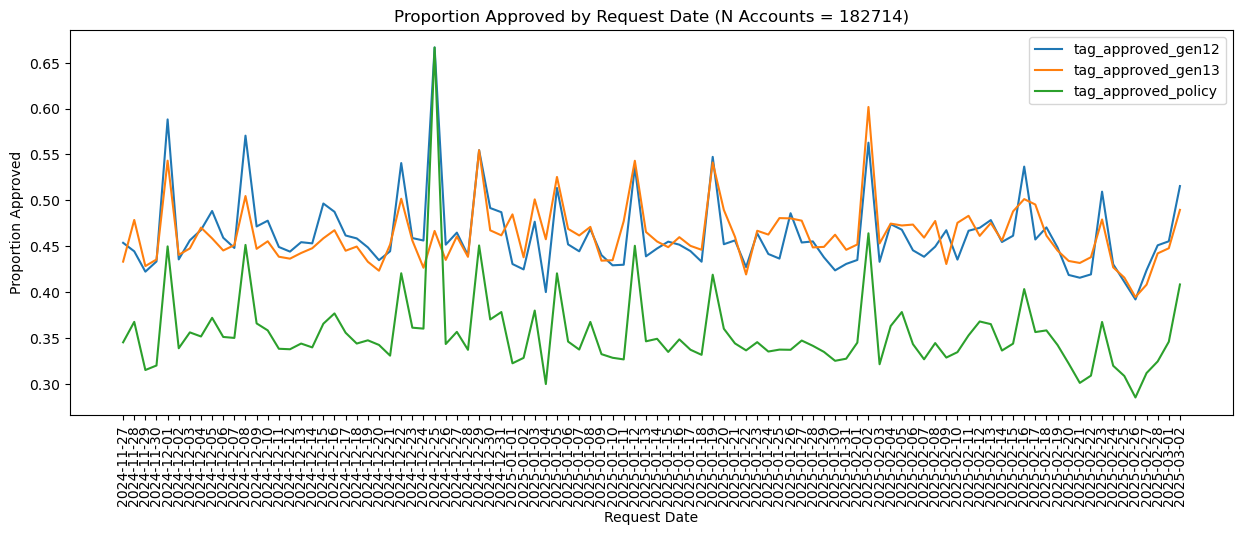

In [46]:
int_nrows = df.shape[0]
df_tmp['request_date'] = df_tmp['request_datetime'].dt.date
df_tmp2 = df_tmp.groupby(by='request_date', as_index=False).agg({
    'ecnl_gen12': 'mean',
    'ecnl_gen13': 'mean',
    'ecnl_policy': 'mean',
    'tag_approved_gen12': 'mean',
    'tag_approved_gen13': 'mean',
    'tag_approved_policy': 'mean',
})
# get estimated approval rate
df_tmp2['approval_rate_policy'] = (df_tmp2['tag_approved_policy'] * 0.20) / df_tmp2['tag_approved_gen12']

# graph
x = df_tmp2['request_date'].astype(str)
list_cols = [
    'tag_approved_gen12',
    'tag_approved_gen13',
    'tag_approved_policy',
    #'approval_rate_policy',
]
fig, ax = plt.subplots(figsize=(15,5))
str_title = f'Proportion Approved by Request Date (N Accounts = {int_nrows})'
ax.set_title(str_title)
ax.set_xlabel('Request Date')
ax.set_ylabel('Proportion Approved')
for col in list_cols:
    ax.plot(x, df_tmp2[col], label=col)
# x ticks
ax.set_xticklabels(x, rotation=90)
ax.legend()
plt.show()